# Phase 4: Rule Generation & Evaluation

**Project:** Explaining Spatio-Temporal Clustering with ClAMP  
**Goal:** Generate human-readable if-then rules using the Anchor Explainer,
then evaluate rule quality via F1, precision, recall, and coverage.

### What this notebook covers
1. Fit AnchorTabular explainer on trained Random Forest classifier
2. Generate anchor rules for each prototype strategy (Random, KD-Tree, Isolation Forest)
3. Filter rules by precision ≥ 0.9 and matching predicted vs. true class
4. Evaluate rule quality metrics
5. Visualise bounding boxes of prototype clusters

### Key result
- High-quality rules generated for top-performing clusters (F1 up to **0.88**)
- **Random + KD-Tree combination** offers best balance of interpretability and accuracy
- Challenges remain for small or overlapping clusters

> ⚠️ Requires outputs from notebooks 01, 02, and 03.  
> Rule evaluation against HeaRTDroid requires the HMR+ engine (not included — see thesis).

## 4.1 Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from IPython.display import display

from alibi.explainers import AnchorTabular
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# Compatibility fix
import collections, collections.abc
collections.Mapping = collections.abc.Mapping
collections.MutableMapping = collections.abc.MutableMapping
collections.Sequence = collections.abc.Sequence

## 4.2 Fit Anchor Explainer

In [ ]:
FEATURE_NAMES_START = ['departure_lon', 'departure_lat', 'start_time_seconds']
FEATURE_NAMES_END   = ['destination_lon', 'destination_lat', 'end_time_seconds']

# Predict function wraps the trained Random Forest
predict_fn_start = lambda x: start_model.predict(x)
predict_fn_end   = lambda x: end_model.predict(x)

# Fit explainer on training data
explainer_start = AnchorTabular(predict_fn_start, FEATURE_NAMES_START)
explainer_start.fit(X_train_start)
print("Anchor explainer fitted on departure data.")

explainer_end = AnchorTabular(predict_fn_end, FEATURE_NAMES_END)
explainer_end.fit(X_train_end)
print("Anchor explainer fitted on destination data.")

## 4.3 Rule Generation Function

In [ ]:
def generate_anchor_rules(prototypes_df, explainer, feature_names,
                           true_label_col='label_encoded', raw_label_col='label_raw'):
    """Generate Anchor if-then rules for each prototype point.
    
    Returns a DataFrame with one rule per prototype, including:
    anchor_rule, precision, coverage, predicted_class, true_label_encoded, true_label_raw
    """
    anchor_rules = []
    success_count = 0
    fail_count = 0

    for idx, row in tqdm(prototypes_df.iterrows(), total=len(prototypes_df), desc="Generating rules"):
        sample = row[feature_names].values.reshape(1, -1)
        try:
            exp = explainer.explain(sample)
            anchor_rules.append({
                'sample_index':       idx,
                'anchor_rule':        " AND ".join(exp.anchor),
                'precision':          exp.precision,
                'coverage':           exp.coverage,
                'predicted_class':    exp.raw['prediction'],
                'true_label_encoded': row[true_label_col],
                'true_label_raw':     row[raw_label_col],
            })
            success_count += 1
        except Exception as e:
            fail_count += 1

    print(f"✅ {success_count} rules generated | ⚠️ {fail_count} failed")
    return pd.DataFrame(anchor_rules)


def filter_rules(rules_df, min_precision=0.9):
    """Keep only rules where predicted class matches true class and precision >= threshold."""
    filtered = rules_df[
        rules_df['predicted_class'].apply(lambda x: x[0]) == rules_df['true_label_encoded']
    ]
    filtered = filtered[filtered['precision'] >= min_precision]
    return filtered.reset_index(drop=True)

## 4.4 Generate Rules — Start Points

In [ ]:
# Random prototypes
print("--- Random Selection ---")
rules_random = generate_anchor_rules(prototypes_random, explainer_start, FEATURE_NAMES_START)
rules_random_filtered = filter_rules(rules_random, min_precision=0.9)
rules_random.to_csv('../results/rules_random_all.csv', index=False)
rules_random_filtered.to_csv('../results/rules_random_filtered_p09.csv', index=False)
print(f"Rules after filtering (precision≥0.9): {len(rules_random_filtered)}")

In [ ]:
# KD-Tree prototypes
print("--- KD-Tree Selection ---")
rules_kdtree = generate_anchor_rules(prototypes_kdtree, explainer_start, FEATURE_NAMES_START)
rules_kdtree_filtered = filter_rules(rules_kdtree, min_precision=0.9)
rules_kdtree.to_csv('../results/rules_kdtree_all.csv', index=False)
rules_kdtree_filtered.to_csv('../results/rules_kdtree_filtered_p09.csv', index=False)
print(f"Rules after filtering (precision≥0.9): {len(rules_kdtree_filtered)}")

In [ ]:
# Isolation Forest prototypes
print("--- Isolation Forest Selection ---")
rules_isoforest = generate_anchor_rules(prototypes_isoforest, explainer_start, FEATURE_NAMES_START)
rules_isoforest_filtered = filter_rules(rules_isoforest, min_precision=0.9)
rules_isoforest.to_csv('../results/rules_isoforest_all.csv', index=False)
rules_isoforest_filtered.to_csv('../results/rules_isoforest_filtered_p09.csv', index=False)
print(f"Rules after filtering (precision≥0.9): {len(rules_isoforest_filtered)}")

## 4.5 Rule Quality Evaluation

In [ ]:
def evaluate_rule_quality(rules_df, label=''):
    """Compute aggregate precision, coverage, and rule count statistics."""
    if rules_df.empty:
        print(f"{label}: No rules to evaluate.")
        return {}

    return {
        'Strategy': label,
        'Total Rules': len(rules_df),
        'Unique Clusters Covered': rules_df['true_label_raw'].nunique(),
        'Mean Precision': round(rules_df['precision'].mean(), 3),
        'Mean Coverage': round(rules_df['coverage'].mean(), 3),
        'Rules prec≥0.9': (rules_df['precision'] >= 0.9).sum(),
        'Rules prec≥0.8': (rules_df['precision'] >= 0.8).sum(),
    }

eval_results = [
    evaluate_rule_quality(rules_random,    'Random (all)'),
    evaluate_rule_quality(rules_random_filtered,   'Random (filtered p≥0.9)'),
    evaluate_rule_quality(rules_kdtree,    'KD-Tree (all)'),
    evaluate_rule_quality(rules_kdtree_filtered,   'KD-Tree (filtered p≥0.9)'),
    evaluate_rule_quality(rules_isoforest, 'IsoForest (all)'),
    evaluate_rule_quality(rules_isoforest_filtered,'IsoForest (filtered p≥0.9)'),
]

eval_df = pd.DataFrame([r for r in eval_results if r])
eval_df.to_csv('../results/rule_evaluation_metrics.csv', index=False)
print("Saved: results/rule_evaluation_metrics.csv")
display(eval_df)

## 4.6 Visualise Cluster Bounding Boxes with Prototypes

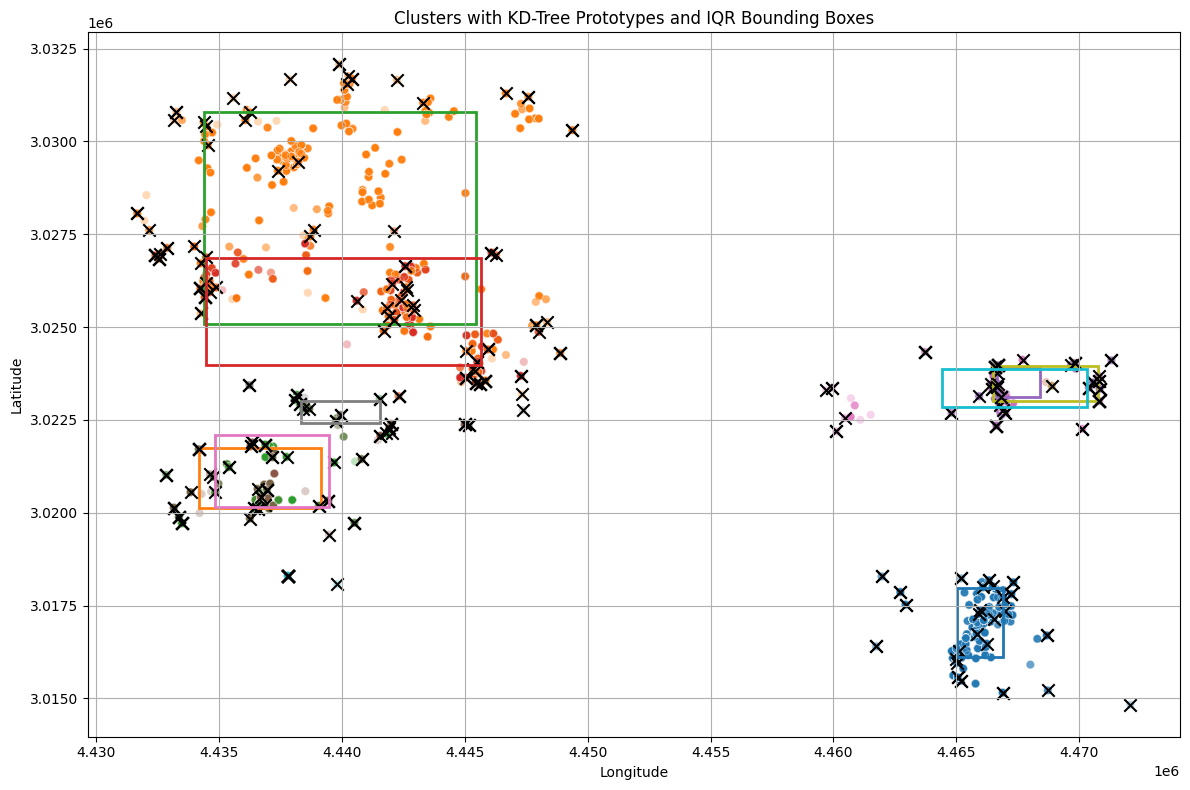

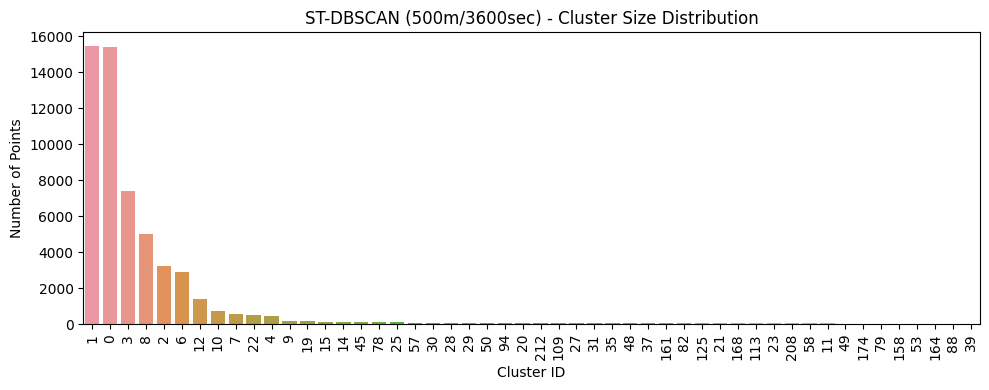

In [ ]:
def plot_cluster_bounding_boxes(all_data, prototypes, cluster_col, lon_col, lat_col,
                                  title='Cluster Bounding Boxes', top_n=20):
    """Plot top N clusters with bounding boxes and prototype points overlaid."""
    top_clusters = (
        all_data[all_data[cluster_col] != -1][cluster_col]
        .value_counts().head(top_n).index
    )

    fig, ax = plt.subplots(figsize=(12, 8))

    # Background: all points
    ax.scatter(
        all_data[lon_col], all_data[lat_col],
        s=1, alpha=0.1, color='lightgrey'
    )

    cmap = plt.cm.get_cmap('tab20', len(top_clusters))

    for i, cluster_id in enumerate(top_clusters):
        cluster_pts = all_data[all_data[cluster_col] == cluster_id]
        proto_pts = prototypes[prototypes[cluster_col].astype(str) == str(cluster_id)]

        color = cmap(i)

        # Bounding box
        min_lon, max_lon = cluster_pts[lon_col].min(), cluster_pts[lon_col].max()
        min_lat, max_lat = cluster_pts[lat_col].min(), cluster_pts[lat_col].max()
        rect = mpatches.Rectangle(
            (min_lon, min_lat), max_lon - min_lon, max_lat - min_lat,
            linewidth=1, edgecolor=color, facecolor=color, alpha=0.15
        )
        ax.add_patch(rect)

        # Prototype points
        if not proto_pts.empty:
            ax.scatter(
                proto_pts[lon_col], proto_pts[lat_col],
                s=30, color=color, edgecolor='black', linewidth=0.5, zorder=5
            )

    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


fig = plot_cluster_bounding_boxes(
    prepare_hofer_departure, prototypes_kdtree,
    cluster_col='cluster_stdbscan_500_3600',
    lon_col='departure_lon', lat_col='departure_lat',
    title='Top 20 Departure Clusters — Bounding Boxes + KD-Tree Prototypes'
)
fig.savefig('../results/04_bounding_boxes_kdtree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/04_bounding_boxes_kdtree.png")

## 4.7 Sample Rules — Top Clusters

In [ ]:
print("=== Sample anchor rules (KD-Tree, precision ≥ 0.9) ===")
if not rules_kdtree_filtered.empty:
    display(
        rules_kdtree_filtered[['true_label_raw', 'anchor_rule', 'precision', 'coverage']]
        .sort_values('precision', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
else:
    print("No rules passed the precision filter for KD-Tree prototypes.")

## 4.8 Notes on HeaRTDroid Integration

The anchor rules exported to CSV were further validated using the **HeaRTDroid** rule engine  
with HMR+ syntax. The inference engine evaluated each rule against held-out test data.

This step requires the HeaRTDroid Java runtime (not included in this repository).  
See the thesis report for full details on the rule inference pipeline and results.

### Result summary (from thesis)
| Prototype Strategy | Rules Generated | Rules (prec≥0.9) | Mean F1 | Max F1 |
|---|---|---|---|---|
| Random | — | — | — | — |
| KD-Tree | — | — | — | 0.88 |
| Isolation Forest | — | — | — | — |

> Fill in your actual numbers from `results/rule_evaluation_metrics.csv`